# FNO2dUQ Predictions

In [210]:
import math
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from model_2d_uq import FNO2dUQ, add_grid
from train_utils import UnitGaussianNormalizer, load_data, relative_l2

In [211]:
# "uq": Gaussian NLL
# "uq2": Beta-NLL

variant = "uq2"
uq2_beta_tag = "b0p7" # only used if "uq2" (use "" for old uq2 files)

mode = 0
difficulty = ["241", "421"]
res = [241, 421]
s_list = [60, 85]

case = difficulty[mode]
r = res[mode]
s = s_list[mode]
n_test = 200

TRAIN_PATH = f"data/piececonst_r{case}_N1024_smooth1.mat"
TEST_PATH = f"data/piececonst_r{case}_N1024_smooth2.mat"
variant_stem = f"fno2d_{variant}"
if variant == "uq2" and uq2_beta_tag:
    variant_stem += f"_{uq2_beta_tag}"
MODEL_PATH = f"outputs/{variant_stem}_{case}_final.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}")

Using cuda


In [212]:
# Load data
a_train, u_train = load_data(TRAIN_PATH, 1000, r, s)
a_test, u_test = load_data(TEST_PATH, n_test, r, s)
a_normalizer = UnitGaussianNormalizer(a_train)
u_normalizer = UnitGaussianNormalizer(u_train)

a_test_raw = a_test.clone()
a_test = add_grid(a_normalizer.encode(a_test))

model = FNO2dUQ(n_modes_x=12, n_modes_y=12, width=32).to(device)

state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
print(f"Model fetched from {MODEL_PATH}")
model.eval()

with torch.no_grad():
    mu_all, sigma_all = model(a_test.to(device))
    mu_all = u_normalizer.decode(mu_all.cpu())
    sigma_all = u_normalizer.decode_scale(sigma_all.cpu())

abs_err_all = (u_test - mu_all).abs()
residual_all = u_test - mu_all

Model fetched from outputs/fno2d_uq2_b0p7_241_final.pt


## Spatial maps

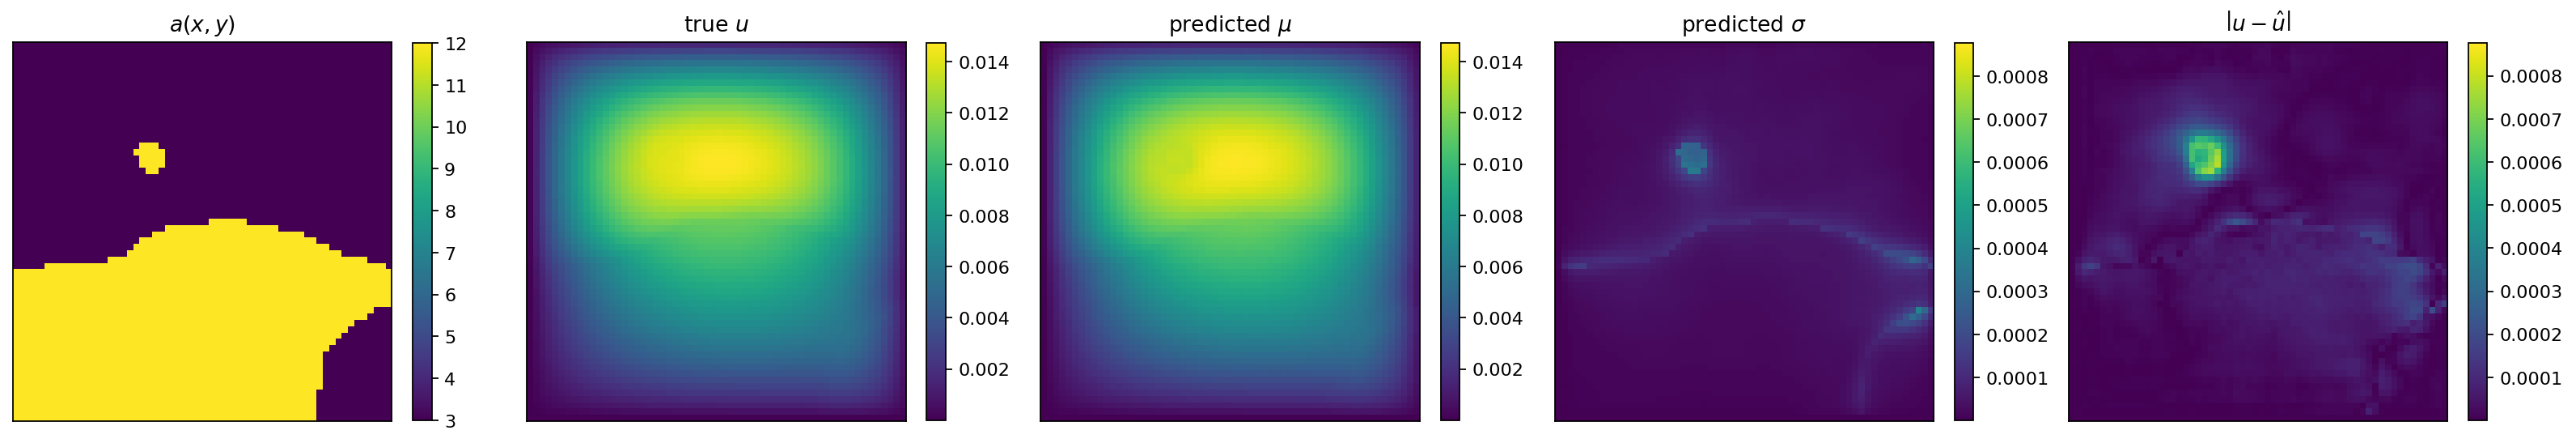

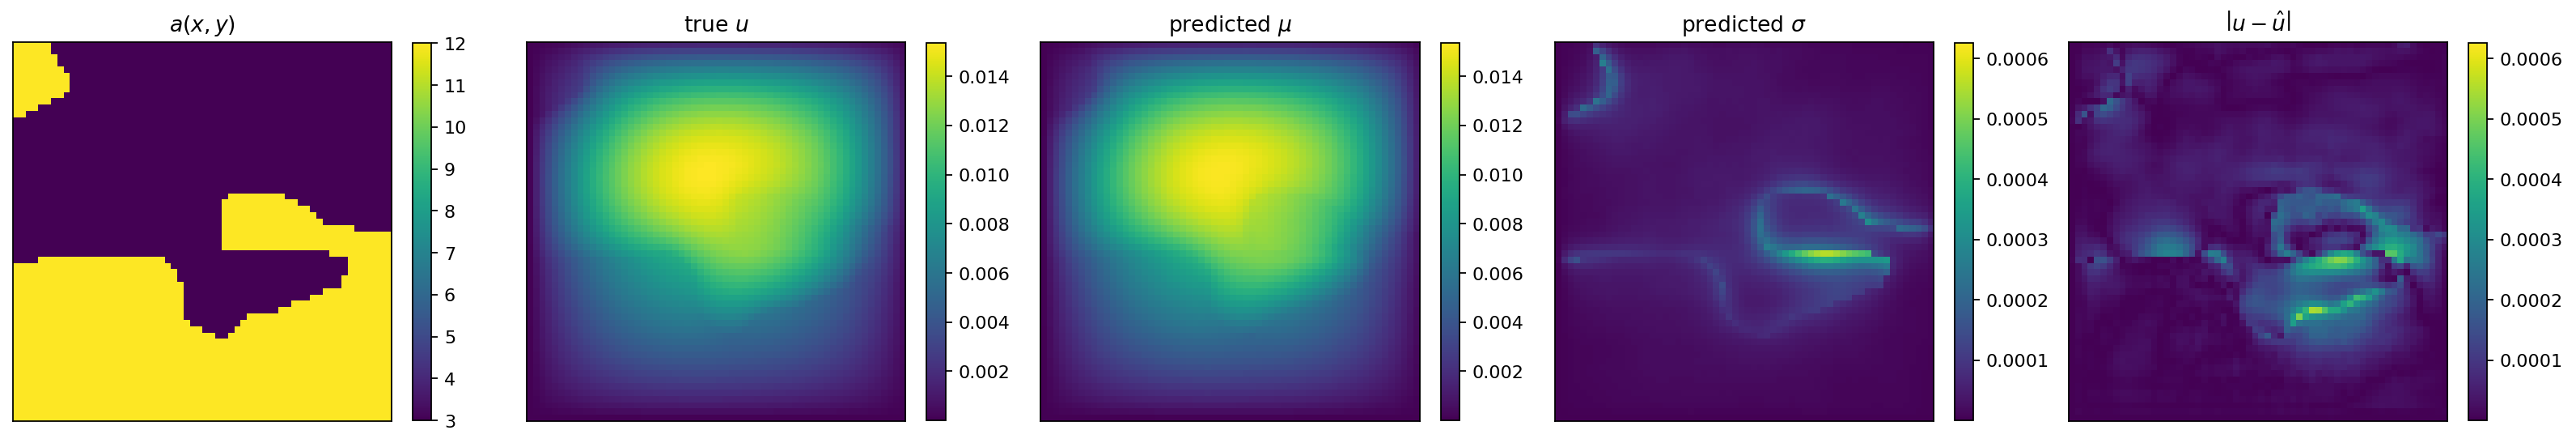

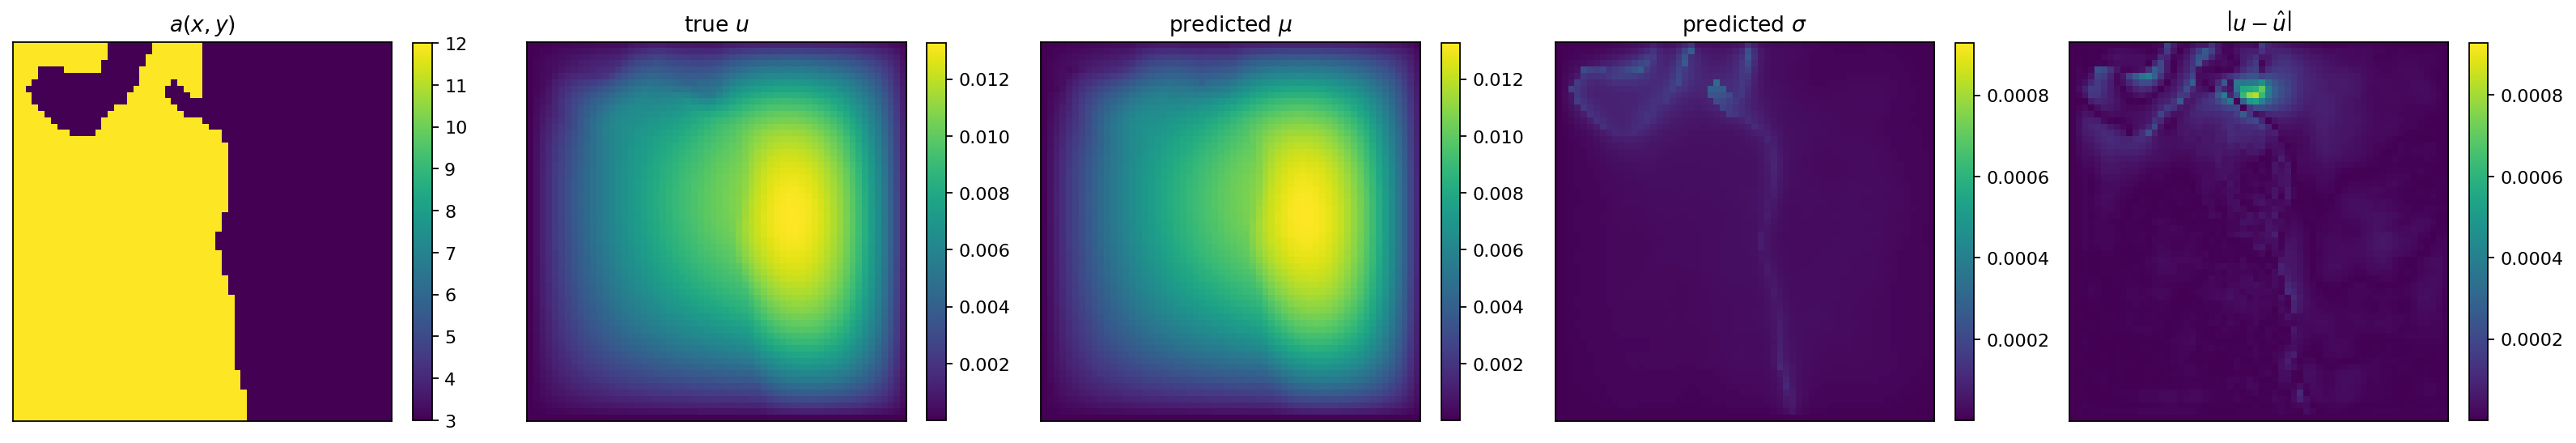

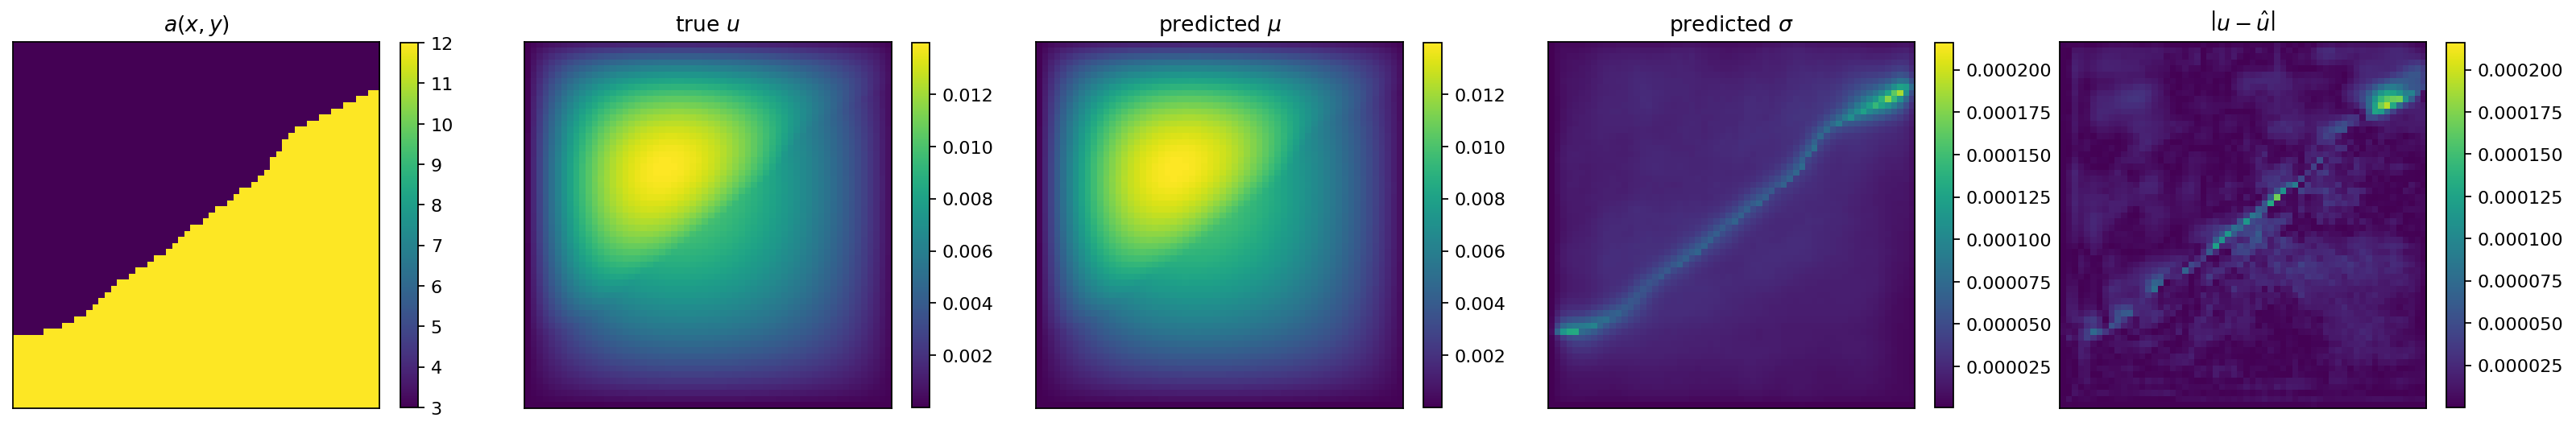

In [213]:
samples = [0, 5, 10, 50]

for idx in samples:
    a = a_test_raw[idx, 0]
    u = u_test[idx, 0]
    mu = mu_all[idx, 0]
    sigma = sigma_all[idx, 0]
    err = abs_err_all[idx, 0]

    same_max = max(err.max().item(), sigma.max().item())

    fig, axes = subplots(1, 5, figsize=(20, 3.5), dpi=160)
    # fig.suptitle(f"Sample {idx}", fontsize=13, y=1.02)

    im0 = axes[0].imshow(a, origin="lower")
    axes[0].set_title(r"$a(x,y)$")

    im1 = axes[1].imshow(u, origin="lower")
    axes[1].set_title(r"true $u$")

    im2 = axes[2].imshow(mu, origin="lower", vmin=u.min(), vmax=u.max())
    axes[2].set_title(r"predicted $\mu$")

    im3 = axes[3].imshow(sigma, origin="lower", vmax=same_max*1.12) # same scale as FNO2D errors
    axes[3].set_title(r"predicted $\sigma$")

    im4 = axes[4].imshow(err, origin="lower", vmax=same_max*1.12)
    axes[4].set_title(r"$\left|u-\hat{u}\right|$")

    plt.colorbar(im0, ax=axes[0], fraction=0.045)
    plt.colorbar(im1, ax=axes[1], fraction=0.045)
    plt.colorbar(im2, ax=axes[2], fraction=0.045)
    plt.colorbar(im3, ax=axes[3], fraction=0.045)
    plt.colorbar(im4, ax=axes[4], fraction=0.045)

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    fig.tight_layout()
    plt.show()

## Uncertainty vs error scatter

C:\Users\Galek\AppData\Local\Temp\ipykernel_4360\2085494704.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


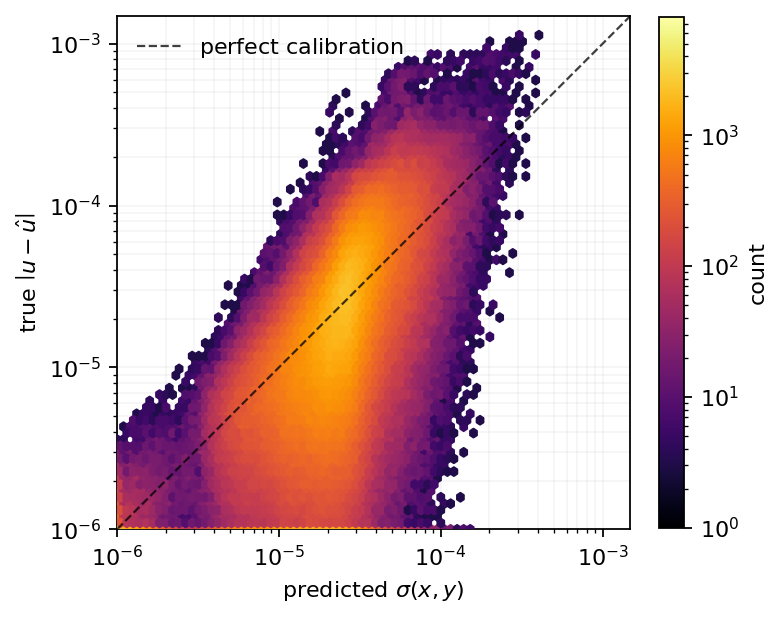

In [222]:
from matplotlib.colors import LogNorm

sig = sigma_all.flatten().numpy()
err = abs_err_all.flatten().numpy()

eps = 1e-6
sig_plot = np.clip(sig, eps, None)
err_plot = np.clip(err, eps, None)
lims = [eps, max(sig_plot.max(), err_plot.max())]

fig, ax = subplots(figsize=(5, 5), dpi=160)
ax.set_aspect("equal")
ax.set_xscale("log")
ax.set_yscale("log")
hb = ax.hexbin(sig_plot, err_plot, gridsize=70, mincnt=3, norm=LogNorm(vmin=1),
               xscale="log", yscale="log", cmap="inferno", alpha=1, zorder=5)
ax.plot(lims, lims, ls="--", c='black', lw=1, alpha=0.75, label=r"$\text{perfect calibration}$", zorder=6)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r"predicted $\sigma(x,y)$")
ax.set_ylabel(r"true $\left|u-\hat{u}\right|$")
ax.legend(frameon=False)
ax.grid(True, which="both", alpha=0.12)
# ax.grid(True, which="minor", alpha=0.12)

plt.colorbar(hb, ax=ax, fraction=0.045, label="count")
fig.tight_layout()
fig.show()

## Normalized residuals

C:\Users\Galek\AppData\Local\Temp\ipykernel_4360\232757818.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


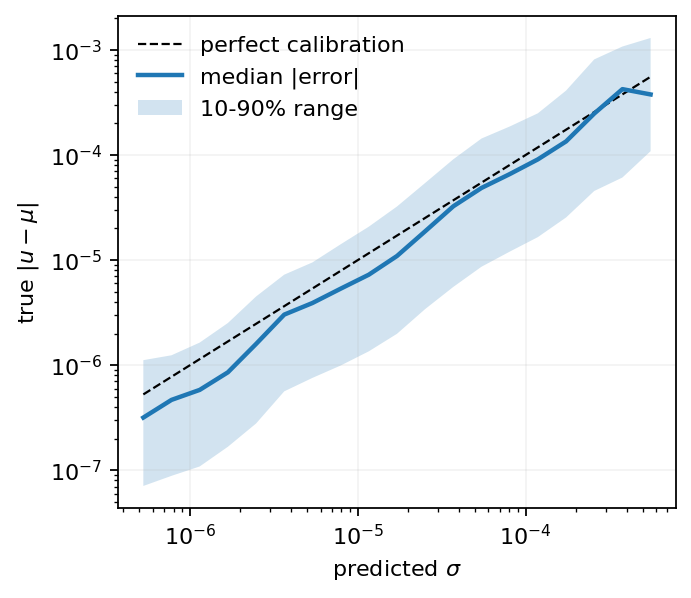

In [221]:
sig = sigma_all.flatten().numpy()
err = abs_err_all.flatten().numpy()

# Bins to essentially collapse the 2D plot into a 1D interpretation
bins = np.logspace(np.log10(sig.min()), np.log10(sig.max()), 20)
centers = np.sqrt(bins[:-1] * bins[1:])
idx = np.digitize(sig, bins)

# Track the median of the error along with the quantile of the data
med = []
q10 = []
q90 = []
for i in range(1, len(bins)):
    e = err[idx == i]
    med.append(np.median(e))
    q10.append(np.quantile(e, 0.1))
    q90.append(np.quantile(e, 0.9))

fig, ax = subplots(figsize=(4.5, 4), dpi=160)

ax.plot(centers, centers, "k--", lw=1, label="perfect calibration")
ax.plot(centers, med, lw=2, label="median |error|")
ax.fill_between(centers, q10, q90, alpha=0.2, label="10-90% range")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"predicted $\sigma$")
ax.set_ylabel(r"true $|u-\mu|$")
ax.legend(frameon=False)
ax.grid(True, which="major", alpha=0.15)

fig.show()